## **STEP 1:- DATA LOADING**

In [1]:
import pandas as pd # Importing the Pandas Library to work with CSV Files

# Creating a dataframe 'df' to store the dataset csv file
df = pd.read_csv("data.csv")

# Displaying the first 5 rows
df.head()

,CSAT_Score,Review,sentiment
0,5,The service was excellent and very fast,Positive
1,4,Support team helped me quickly,Positive
2,1,Very disappointed with the response time,Negative
3,2,The issue was not resolved properly,Negative
4,3,Service was okay but could be better,Neutral


## **STEP 2:- DATA ANALYSIS**

In [2]:
df.info()
# Using the info() function to check the dataype and number of non-null objects in every column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   CSAT_Score  100 non-null    int64 
 1   Review      100 non-null    object
 2   sentiment   100 non-null    object
dtypes: int64(1), object(2)
memory usage: 2.5+ KB


In [3]:
df.describe()
# Using the describe() function
# Count = 100 means there are 100 data points
# Mean = 3.04 means the customer satisfaction is neutral (not very happy,not very unhappy)
# std = 1.42 means the values are fairly spread out
# min = 1 means the lowest rating is 1 (very bad experience)
# 25% = 2 means 25 percent of the customers gave 2 rating
# 50% = 3 means 50 percent of the customers gave 3 rating
# 75% = 4 means 75 percent of the customers gave 4 rating
# max = 5 means the highest rating is 5

,CSAT_Score
count,100.000000
mean,3.040000
std,1.420769
min,1.000000
25%,2.000000
50%,3.000000
75%,4.000000
max,5.000000


In [4]:
df['CSAT_Score'].value_counts()

# This displays the number of data points for every different CSAT_Score
# 21 customers gave 5 rating
# 20 customers gave 4 rating
# 20 customers gave 3 rating
# 20 customers gave 2 rating
# 19 customers gave 1 rating

CSAT_Score
5    21
4    20
2    20
3    20
1    19
Name: count, dtype: int64

In [5]:
df['sentiment'].value_counts()

# This displays the number of data points for every different sentiment value (positive, negative, neutral)
# Positive Reactions are 41
# Negative Reactions are 39
# Neutral Reactions are 20

sentiment
Positive    41
Negative    39
Neutral     20
Name: count, dtype: int64

In [6]:
pd.crosstab(df['CSAT_Score'], df['sentiment'])

# Creating a table combining two features CSAT_Score and sentiment

sentiment,Negative,Neutral,Positive
CSAT_Score,,,
1,19,0,0
2,20,0,0
3,0,20,0
4,0,0,20
5,0,0,21


In [7]:
df['review_length'] = df['Review'].apply(len)
# Creating a new feature review_length which shows the length of each review

df.head()
# Depicting the first 5 rows

,CSAT_Score,Review,sentiment,review_length
0,5,The service was excellent and very fast,Positive,39
1,4,Support team helped me quickly,Positive,30
2,1,Very disappointed with the response time,Negative,40
3,2,The issue was not resolved properly,Negative,35
4,3,Service was okay but could be better,Neutral,36


## **STEP 3:- DATA CLEANING**

In [8]:
df.isnull().sum() # This function displays the number of null or empty values in every row

# There are no null values

CSAT_Score       0
Review           0
sentiment        0
review_length    0
dtype: int64

In [9]:
import re
import nltk
from nltk.corpus import stopwords

# Downloading the stopwords in english which are common words (are, is, this etc)
nltk.download('stopwords') 

# Storing the stopwords in the variable stop_words
stop_words = set(stopwords.words('english'))

# Creating the function to clean the text
def cleaning_text(text):
    text = text.lower() # converting the text to lowercase to mantain text consistency
    text = re.sub(r'[^a-zA-Z\s]', '', text) # removing the punctuation symbols
    words = text.split() # splitting the text into words
    words = [word for word in words if word not in stop_words] # removing the stopwords
    return " ".join(words) # joining the words without stopwords and punctuation marks

# Apply ONLY to review column
df["Review"] = df["Review"].astype(str).apply(cleaning_text)

# Displaying the first 5 rows
df.head()

[nltk_data] Downloading package stopwords to /home/nag/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,CSAT_Score,Review,sentiment,review_length
0,5,service excellent fast,Positive,39
1,4,support team helped quickly,Positive,30
2,1,disappointed response time,Negative,40
3,2,issue resolved properly,Negative,35
4,3,service okay could better,Neutral,36


## **STEP 4:- FEATURE ENGINEERING**

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer # Importing the tools to convert text into numerics

# Creating the tool 'vectorizer' to convert the text into numbers because Machine Learning only understands numbers
vectorizer = TfidfVectorizer(max_features=1000) # max_features = 1000 means select only top 1000 words and ignore the other words
X_text = vectorizer.fit_transform(df['Review']) # converting only the review column text into numbers


from sklearn.preprocessing import LabelEncoder # Importing LabelEncoder to perform encoding

# Creating a tool for encoding
le = LabelEncoder()

# Applying the encoding tool only to the sentiment column
df['sentiment'] = le.fit_transform(df['sentiment'])


import numpy as np # importing the numpy library to operate on numericals

X = np.hstack((X_text.toarray(), df[['sentiment']].values)) # Joining the two columns X_text and sentiment side by side as the input
y = df['CSAT_Score'] # choosing the output as CSAT_Score

## **STEP 5:- MODELS DEVELOPMENT**

## Model 1:- Logistic Regression

In [11]:
from sklearn.model_selection import train_test_split, GridSearchCV
# Importing the libraries to split the dataset and GridSearchCV


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Splitting the dataset into training and testing (0.3 or 30 % for testing and remaining for training)

from sklearn.linear_model import LogisticRegression
# importing the library for the model Logistic Regression


# Step 1: Define model
logistic_model = LogisticRegression(max_iter=1000)

# Step 2: Define parameter grid (different values for every parameter)
lr_params = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2']
}

# Step 3: Creating grid which is created by the model and the param grid
grid = GridSearchCV(logistic_model, lr_params, cv=5)

# Step 4: Training the model
grid.fit(X_train, y_train)

# Step 5: Displaying the best parameters
print("Best Params:", grid.best_params_)

# Step 6: Storing the best model
best_model_logistic = grid.best_estimator_

Best Params: {'C': 1, 'penalty': 'l2'}


## MODELS EVALUATION

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
# Importing the libraries for the metrics for evaluation

# storing the result after prediction in the variable y_pred
y_pred = best_model_logistic.predict(X_test)

# storing the accuracy score for this model in the variable lr_acc
lr_acc = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(lr_acc * 100)) # displaying the accuracy score in percentage

print('-----------------------------')

# displaying the classification report which consists precision, recall and f1-score
print("Classification Report", classification_report(y_test, y_pred))

Accuracy: 70.00%
-----------------------------
Classification Report               precision    recall  f1-score   support

           1       1.00      0.50      0.67         4
           2       0.71      1.00      0.83         5
           3       1.00      1.00      1.00         7
           4       1.00      0.22      0.36         9
           5       0.42      1.00      0.59         5

    accuracy                           0.70        30
   macro avg       0.83      0.74      0.69        30
weighted avg       0.86      0.70      0.67        30



Text(0.5, 1.0, 'Confusion Matrix for Logistic Regression')

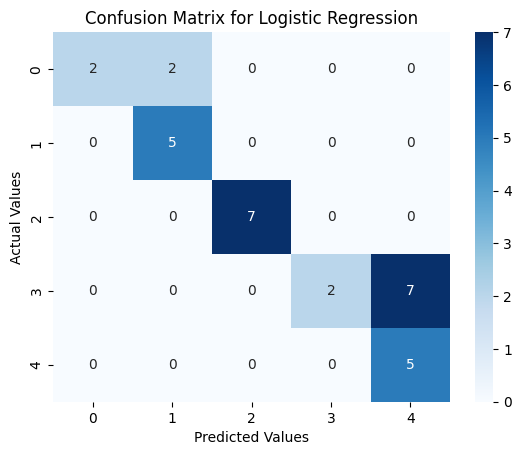

In [13]:
# Storing the confusion matrix which consists (true_positive, false_positive, true_negative, false-negative)
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix for Logistic Regression')

## Model 2:- Random Forest Classifier

In [14]:
from sklearn.ensemble import RandomForestClassifier
# importing the library for the model Random Forest Classifier

# Step 1: Define model
Random_Forest = RandomForestClassifier(random_state=42)

# Step 2: Define parameter grid (different values for every parameter)
rf_params = {
    'n_estimators': [10, 50, 100],
    'max_depth': [10, 20, 30]
}

# Step 3: Creating grid which is created by the model and the param grid
grid = GridSearchCV(Random_Forest, rf_params, cv=5)

# Step 4: Training the model
grid.fit(X_train, y_train)

# Step 5: Displaying the best parameters
print("Best Parameters:", grid.best_params_)

# Step 6: Storing the best model
best_model_forest = grid.best_estimator_

Best Parameters: {'max_depth': 20, 'n_estimators': 10}


## Model Evaluation

In [15]:
# storing the result after prediction in the variable y_pred
y_pred = best_model_forest.predict(X_test)

# storing the accuracy score for this model in the variable rf_acc
rf_acc = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(rf_acc * 100)) # displaying the accuracy score in percentage

print('-----------------------------')

# displaying the classification report which consists precision, recall and f1-score
print("Classification Report", classification_report(y_test, y_pred))

Accuracy: 76.67%
-----------------------------
Classification Report               precision    recall  f1-score   support

           1       1.00      0.50      0.67         4
           2       0.71      1.00      0.83         5
           3       1.00      1.00      1.00         7
           4       1.00      0.44      0.62         9
           5       0.50      1.00      0.67         5

    accuracy                           0.77        30
   macro avg       0.84      0.79      0.76        30
weighted avg       0.87      0.77      0.76        30



Text(0.5, 1.0, 'Confusion Matrix for Random Forest Classifier')

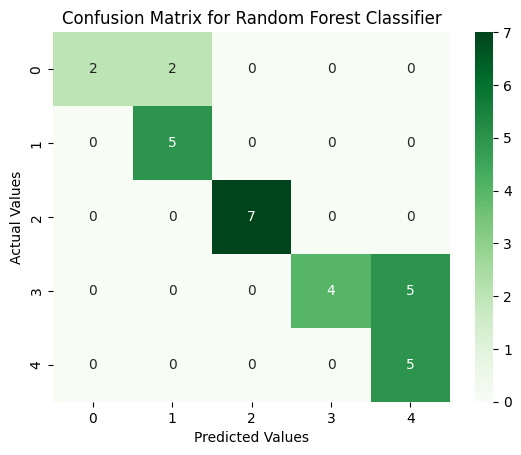

In [16]:
# Storing the confusion matrix which consists (true_positive, false_positive, true_negative, false-negative)
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix for Random Forest Classifier')

## Model 3:- XG-Boost Classifier

In [17]:
from xgboost import XGBClassifier
# importing the library for the model XG-Boost Classifier

# XGBoost Classifier expects the output should be [0,1,2,3,4] but the output is [1,2,3,4,5]

y_train = y_train - 1 # converting the training output [1-1=0, 2-1=1, 3-1=2, 4-1=3, 5-1=4] so the output becomes [0,1,2,3,4]
y_test = y_test - 1 # applying the same process to the output in testing

# Step 1: Define parameter grid (different values for every parameter)
xgb_params = {
    'n_estimators': [10, 50, 100],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
}


# Step 1: Define model
xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=5,
    eval_metric='mlogloss',
    random_state=42
)

# Step 3: Creating grid which is created by the model and the param grid
grid = GridSearchCV(xgb_model, xgb_params, cv=3)

# Step 4: Training the model
grid.fit(X_train, y_train)

# Step 5: Displaying the best parameters
print("Best Params:", grid.best_params_)

# Step 6: Storing the best model
best_xgb_model = grid.best_estimator_

Best Params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 10}


## Model Evaluation

In [18]:
# storing the result after prediction in the variable y_pred
y_pred = best_xgb_model.predict(X_test)

# storing the accuracy score for this model in the variable xgb_acc
xgb_acc = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(xgb_acc * 100)) # displaying the accuracy score in percentage

print('-----------------------------')

# displaying the classification report which consists precision, recall and f1-score
print("Classification Report", classification_report(y_test, y_pred))

Accuracy: 56.67%
-----------------------------
Classification Report               precision    recall  f1-score   support

           0       0.40      0.50      0.44         4
           1       0.50      0.40      0.44         5
           2       1.00      1.00      1.00         7
           3       1.00      0.11      0.20         9
           4       0.38      1.00      0.56         5

    accuracy                           0.57        30
   macro avg       0.66      0.60      0.53        30
weighted avg       0.73      0.57      0.52        30



Text(0.5, 1.0, 'Confusion Matrix for Random Forest Classifier')

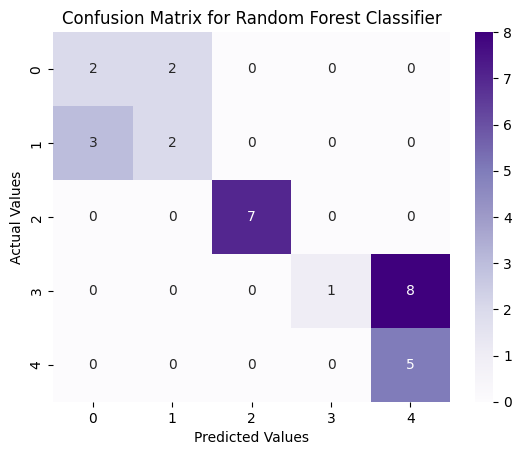

In [19]:
# Storing the confusion matrix which consists (true_positive, false_positive, true_negative, false-negative)
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.xlabel('Predicted Values')
plt.ylabel('Actual Values')
plt.title('Confusion Matrix for Random Forest Classifier')

## **STEP 6:- MODEL COMPARISON**

In [20]:
# Comparing the three models based on the accuracy score
print("Accuracy For Logistic Regression: {:.2f}%".format(lr_acc * 100))
print("Accuracy For Random Forest Classifier: {:.2f}%".format(rf_acc * 100))
print("Accuracy For XG-Boost Classifier: {:.2f}%".format(xgb_acc * 100))

Accuracy For Logistic Regression: 70.00%
Accuracy For Random Forest Classifier: 76.67%
Accuracy For XG-Boost Classifier: 56.67%


## **STEP 7:- MODEL AND DATASET SAVING**

In [21]:
# saving the cleaned dataset
df.to_csv('cleaned_dataset.csv', index=False)

import pickle # importing the pickle library to save the best model

# opening a file called tfidf.pkl
with open("tfidf.pkl", 'wb') as file:
    pickle.dump(vectorizer, file) # storing the vectorizer

# opening a file called random_forest_model.pkl
with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(best_model_forest, file) # storing the best model in the file

print("Sucessfully Saved the Best Model, Vectorizer and Dataset")

Sucessfully Saved the Best Model, Vectorizer and Dataset
